<a href="https://colab.research.google.com/github/GeorgeTak/Python_with_sports_2026/blob/main/Case_Study_9_Players_Statistics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
from google.colab import files
files.upload()

Saving SuperLeague24_25-RegularSeason-PlayersPct.csv to SuperLeague24_25-RegularSeason-PlayersPct (1).csv


{'SuperLeague24_25-RegularSeason-PlayersPct (1).csv': b'Player,ShotPct,PassPct,ThroughBallsPct,DuelsPct,DribblePct\r\nFrancisco Ortega,0,35.571428571428569,0,55.038759689922479,81.25\r\nGiulian Biancone,25,37.384615384615387,0,56.12244897959183,28.571428571428569\r\nLorenzo Pirola,50,36.928571428571431,0,74.242424242424249,0\r\nMarko Stamenic,0,21.428571428571427,0,54.54545454545454,100\r\nAyoub El Kaabi,47.435897435897431,12.708333333333332,0,42.788461538461533,23.076923076923077\r\nGelson Martins,30.555555555555557,22,0,45.664739884393065,36.84210526315789\r\nKristoffer Velde,34.285714285714285,12.555555555555554,0,56.024096385542165,26.829268292682929\r\nDani Garc\xeda,0,25.642857142857142,0,57.3170731707317,550\r\nRoman Yaremchuk,23.076923076923077,3.2666666666666666,0,26.530612244897959,36.363636363636367\r\nGiorgos Masouras,50,3,0,71.428571428571431,0\r\nChiquinho,48.484848484848484,19.666666666666668,0,43.243243243243242,20.833333333333336\r\nRodinei,36.363636363636367,29.647058

In [ ]:
# Assuming your file is a CSV
df = pd.read_csv('SuperLeague24_25-RegularSeason-PlayersPct.csv',encoding='latin-1')

# Display the first 5 rows to verify
display(df.head())

,Player,ShotPct,PassPct,ThroughBallsPct,DuelsPct,DribblePct
0,Francisco Ortega,0.000000,35.571429,0,55.038760,81.250000
1,Giulian Biancone,25.000000,37.384615,0,56.122449,28.571429
2,Lorenzo Pirola,50.000000,36.928571,0,74.242424,0.000000
3,Marko Stamenic,0.000000,21.428571,0,54.545455,100.000000
4,Ayoub El Kaabi,47.435897,12.708333,0,42.788462,23.076923


In [ ]:
print("\nΔιπλότυπα στο DataFrame:")
print(df.duplicated().sum())
# Για να δούμε το πλήθος των μοναδικών τιμών στη στήλη Player
print(df['Player'].nunique())

# Εύρεση διπλότυπων εγγραφών με ίδιο όνομα στη στήλη PLayer
# keep=False εμφανίζει όλες τις εγγραφές με το ίδιο όνομα
duplicates = df[df['Player'].duplicated(keep=False)]

print("\nΕγγραφές με το ίδιο όνομα παίκτη:")
print(duplicates)
df = df.drop_duplicates(subset=['Player'], keep='first')
#print(df['ThroughBallsPct'].value_counts())
#df = df.drop(columns='ThroughBallsPct')
print("\nΣτατιστικά στοιχεία:")
print(df.describe())



Διπλότυπα στο DataFrame:
0
663

Εγγραφές με το ίδιο όνομα παίκτη:
Empty DataFrame
Columns: [Player, ShotPct, PassPct, DuelsPct, DribblePct]
Index: []

Στατιστικά στοιχεία:
          ShotPct     PassPct    DuelsPct  DribblePct
count  663.000000  663.000000  663.000000  663.000000
mean    23.010054   18.984430   50.378480   67.631675
std     26.391817   12.884809   18.928066  114.398539
min      0.000000    0.000000    0.000000    0.000000
25%      0.000000    9.345238   41.407708    0.000000
50%     16.666667   16.400000   50.000000   31.372549
75%     40.000000   26.439130   58.181818   85.714286
max    100.000000   78.000000  100.000000  900.000000


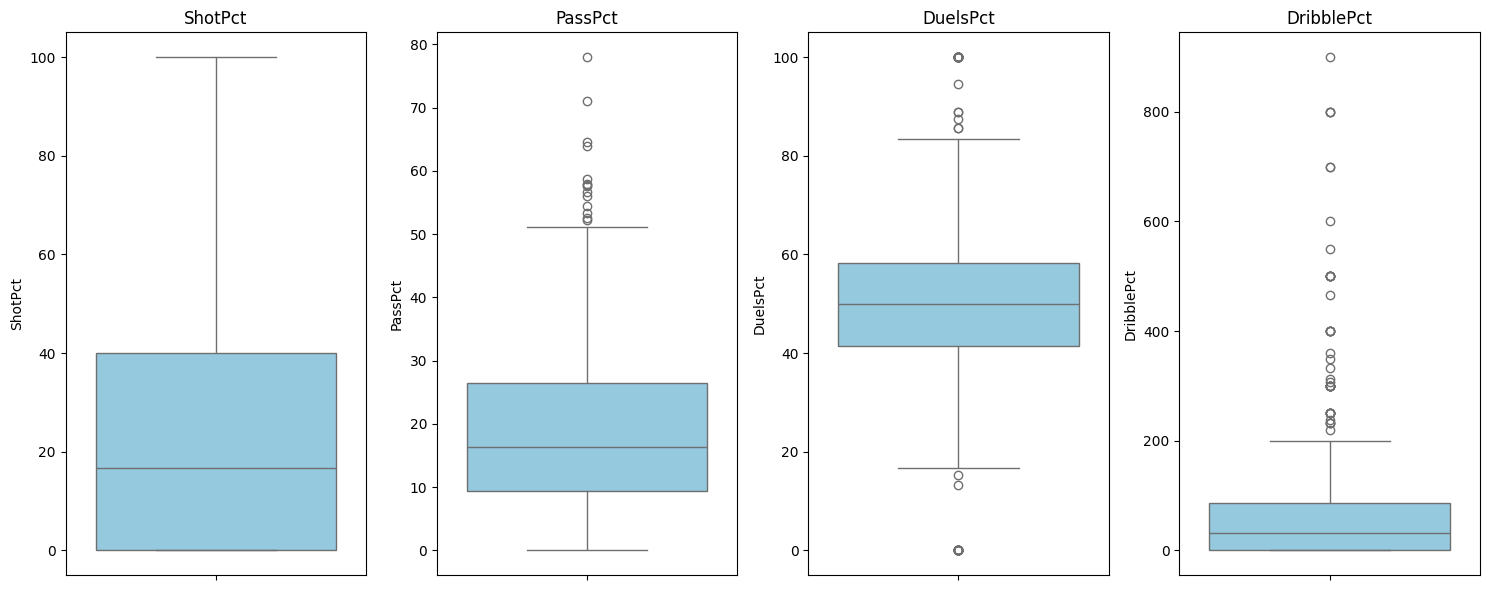

In [ ]:
# Ρύθμιση μεγέθους γραφημάτων
plt.figure(figsize=(15, 6))

# Λίστα με τα ποσοστά
percentage_columns = ['ShotPct', 'PassPct', 'DuelsPct', 'DribblePct']

# Δημιουργία ενός "boxplot" για κάθε ποσοστό
for i, col in enumerate(percentage_columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

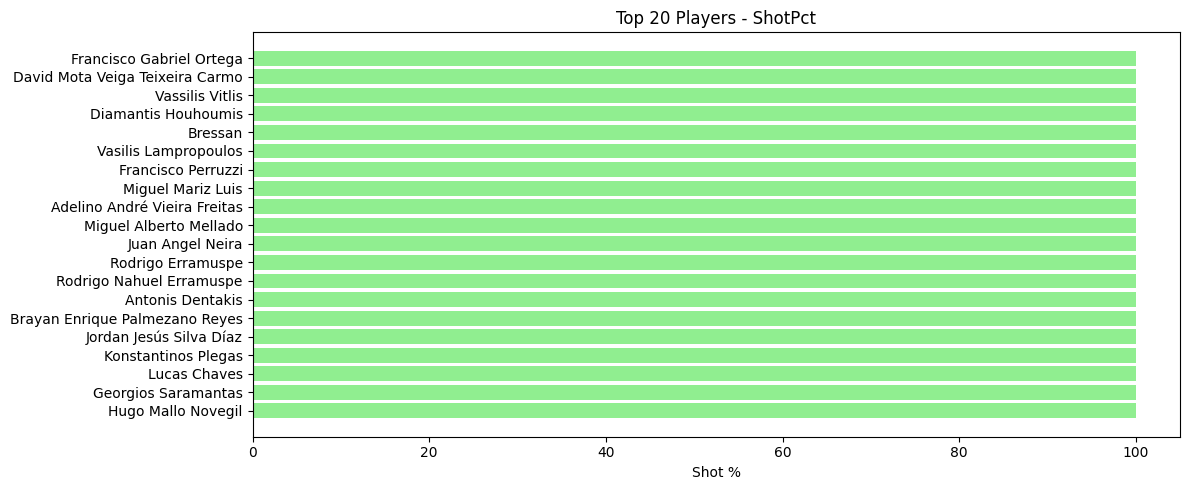

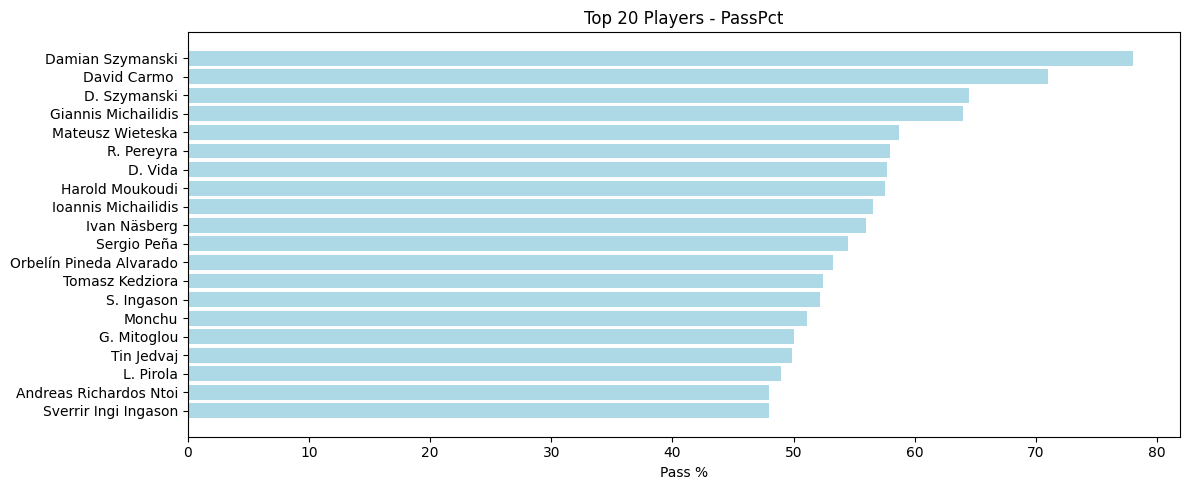

In [ ]:
# Επιλογή των κορυφαίων 20 παικτών σε ShotPct και PassPct
top_20_shot = df.nlargest(20, 'ShotPct')
top_20_pass = df.nlargest(20, 'PassPct')

# Bar Plot για ShotPct
plt.figure(figsize=(12, 5))
plt.barh(top_20_shot['Player'], top_20_shot['ShotPct'], color='lightgreen')
plt.title('Top 20 Players - ShotPct')
plt.xlabel('Shot %')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Bar Plot για PassPct
plt.figure(figsize=(12, 5))
plt.barh(top_20_pass['Player'], top_20_pass['PassPct'], color='lightblue')
plt.title('Top 20 Players - PassPct')
plt.xlabel('Pass %')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

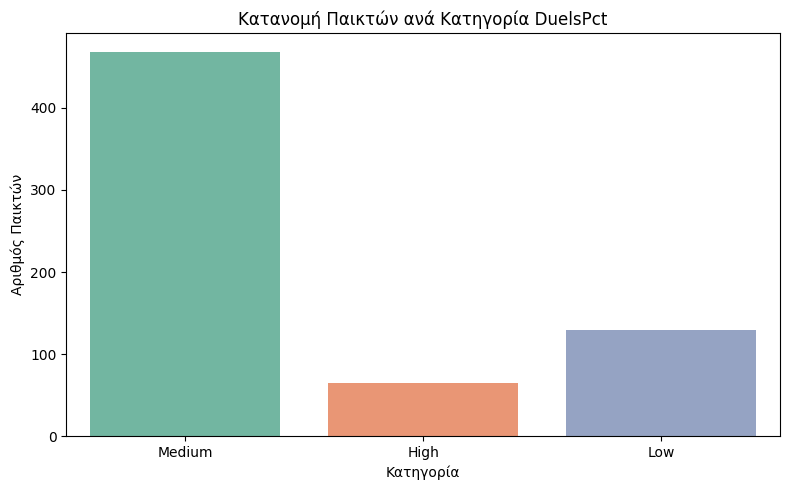

In [ ]:
def categorize_duels(pct):
    if pct > 70:
        return 'High'
    elif 40 <= pct <= 70:
        return 'Medium'
    else:
        return 'Low'

df['Duels_Category'] = df['DuelsPct'].apply(categorize_duels)

# Δημιουργία Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Duels_Category', data=df, hue='Duels_Category', palette='Set2')
plt.title('Κατανομή Παικτών ανά Κατηγορία DuelsPct')
plt.xlabel('Κατηγορία')
plt.ylabel('Αριθμός Παικτών')
plt.tight_layout()
plt.show()

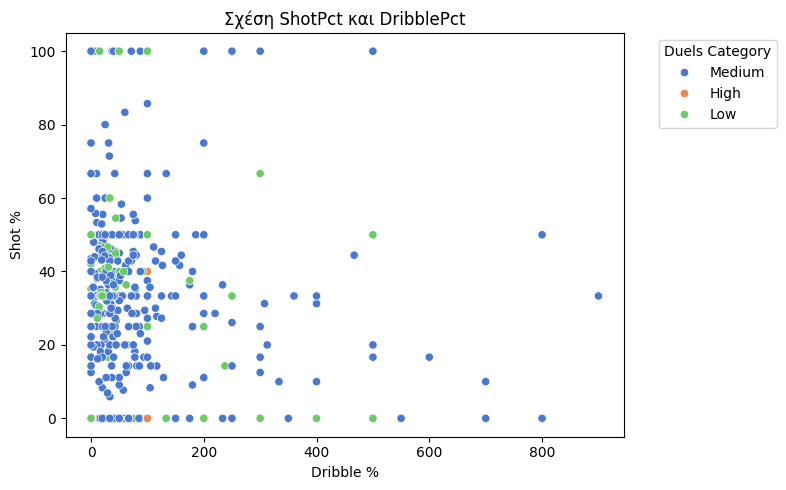

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='DribblePct', y='ShotPct', data=df, hue='Duels_Category', palette='muted')
plt.title('Σχέση ShotPct και DribblePct')
plt.xlabel('Dribble %')
plt.ylabel('Shot %')
plt.legend(title='Duels Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()